In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargamos nuestros datos limpios
df_empleo = pd.read_csv('datos_ods8_veracruz_tabasco.csv')


f = r"reportes_chapopote_limpios.csv"


df_derrames = pd.read_csv(f)

# 2. Calculamos los totales por municipio 
resumen_mun = df_empleo.groupby(['mun', 'Estatus_Laboral'])['Total_Personas'].sum().unstack(fill_value=0)

# 3. Calculamos la Tasa de Desempleo = (No Trabaja / Total) * 100
resumen_mun['Poblacion_Activa'] = resumen_mun['Trabaja'] + resumen_mun['No Trabaja (Desocupado)']
resumen_mun['Tasa_Desempleo_%'] = (resumen_mun['No Trabaja (Desocupado)'] / resumen_mun['Poblacion_Activa']) * 100

# 4. Traemos los derrames para ver si hay relación
conteos_derrame = df_derrames['MUN'].value_counts().reset_index()
conteos_derrame.columns = ['mun_nombre', 'total_derrames']

# Limpiamos el índice para graficar fácilmente
resumen_mun = resumen_mun.reset_index()
resumen_mun = resumen_mun.sort_values('Tasa_Desempleo_%', ascending=True)

print("Datos listos para la historia:")
display(resumen_mun.tail())

Datos listos para la historia:


Estatus_Laboral,mun,No Trabaja (Desocupado),Trabaja,Poblacion_Activa,Tasa_Desempleo_%
59,119.0,612,7344,7956,7.692308
54,108.0,8472,90634,99106,8.548423
61,123.0,716,7045,7761,9.225615
64,131.0,8679,76401,85080,10.200987
45,85.0,2628,13140,15768,16.666667


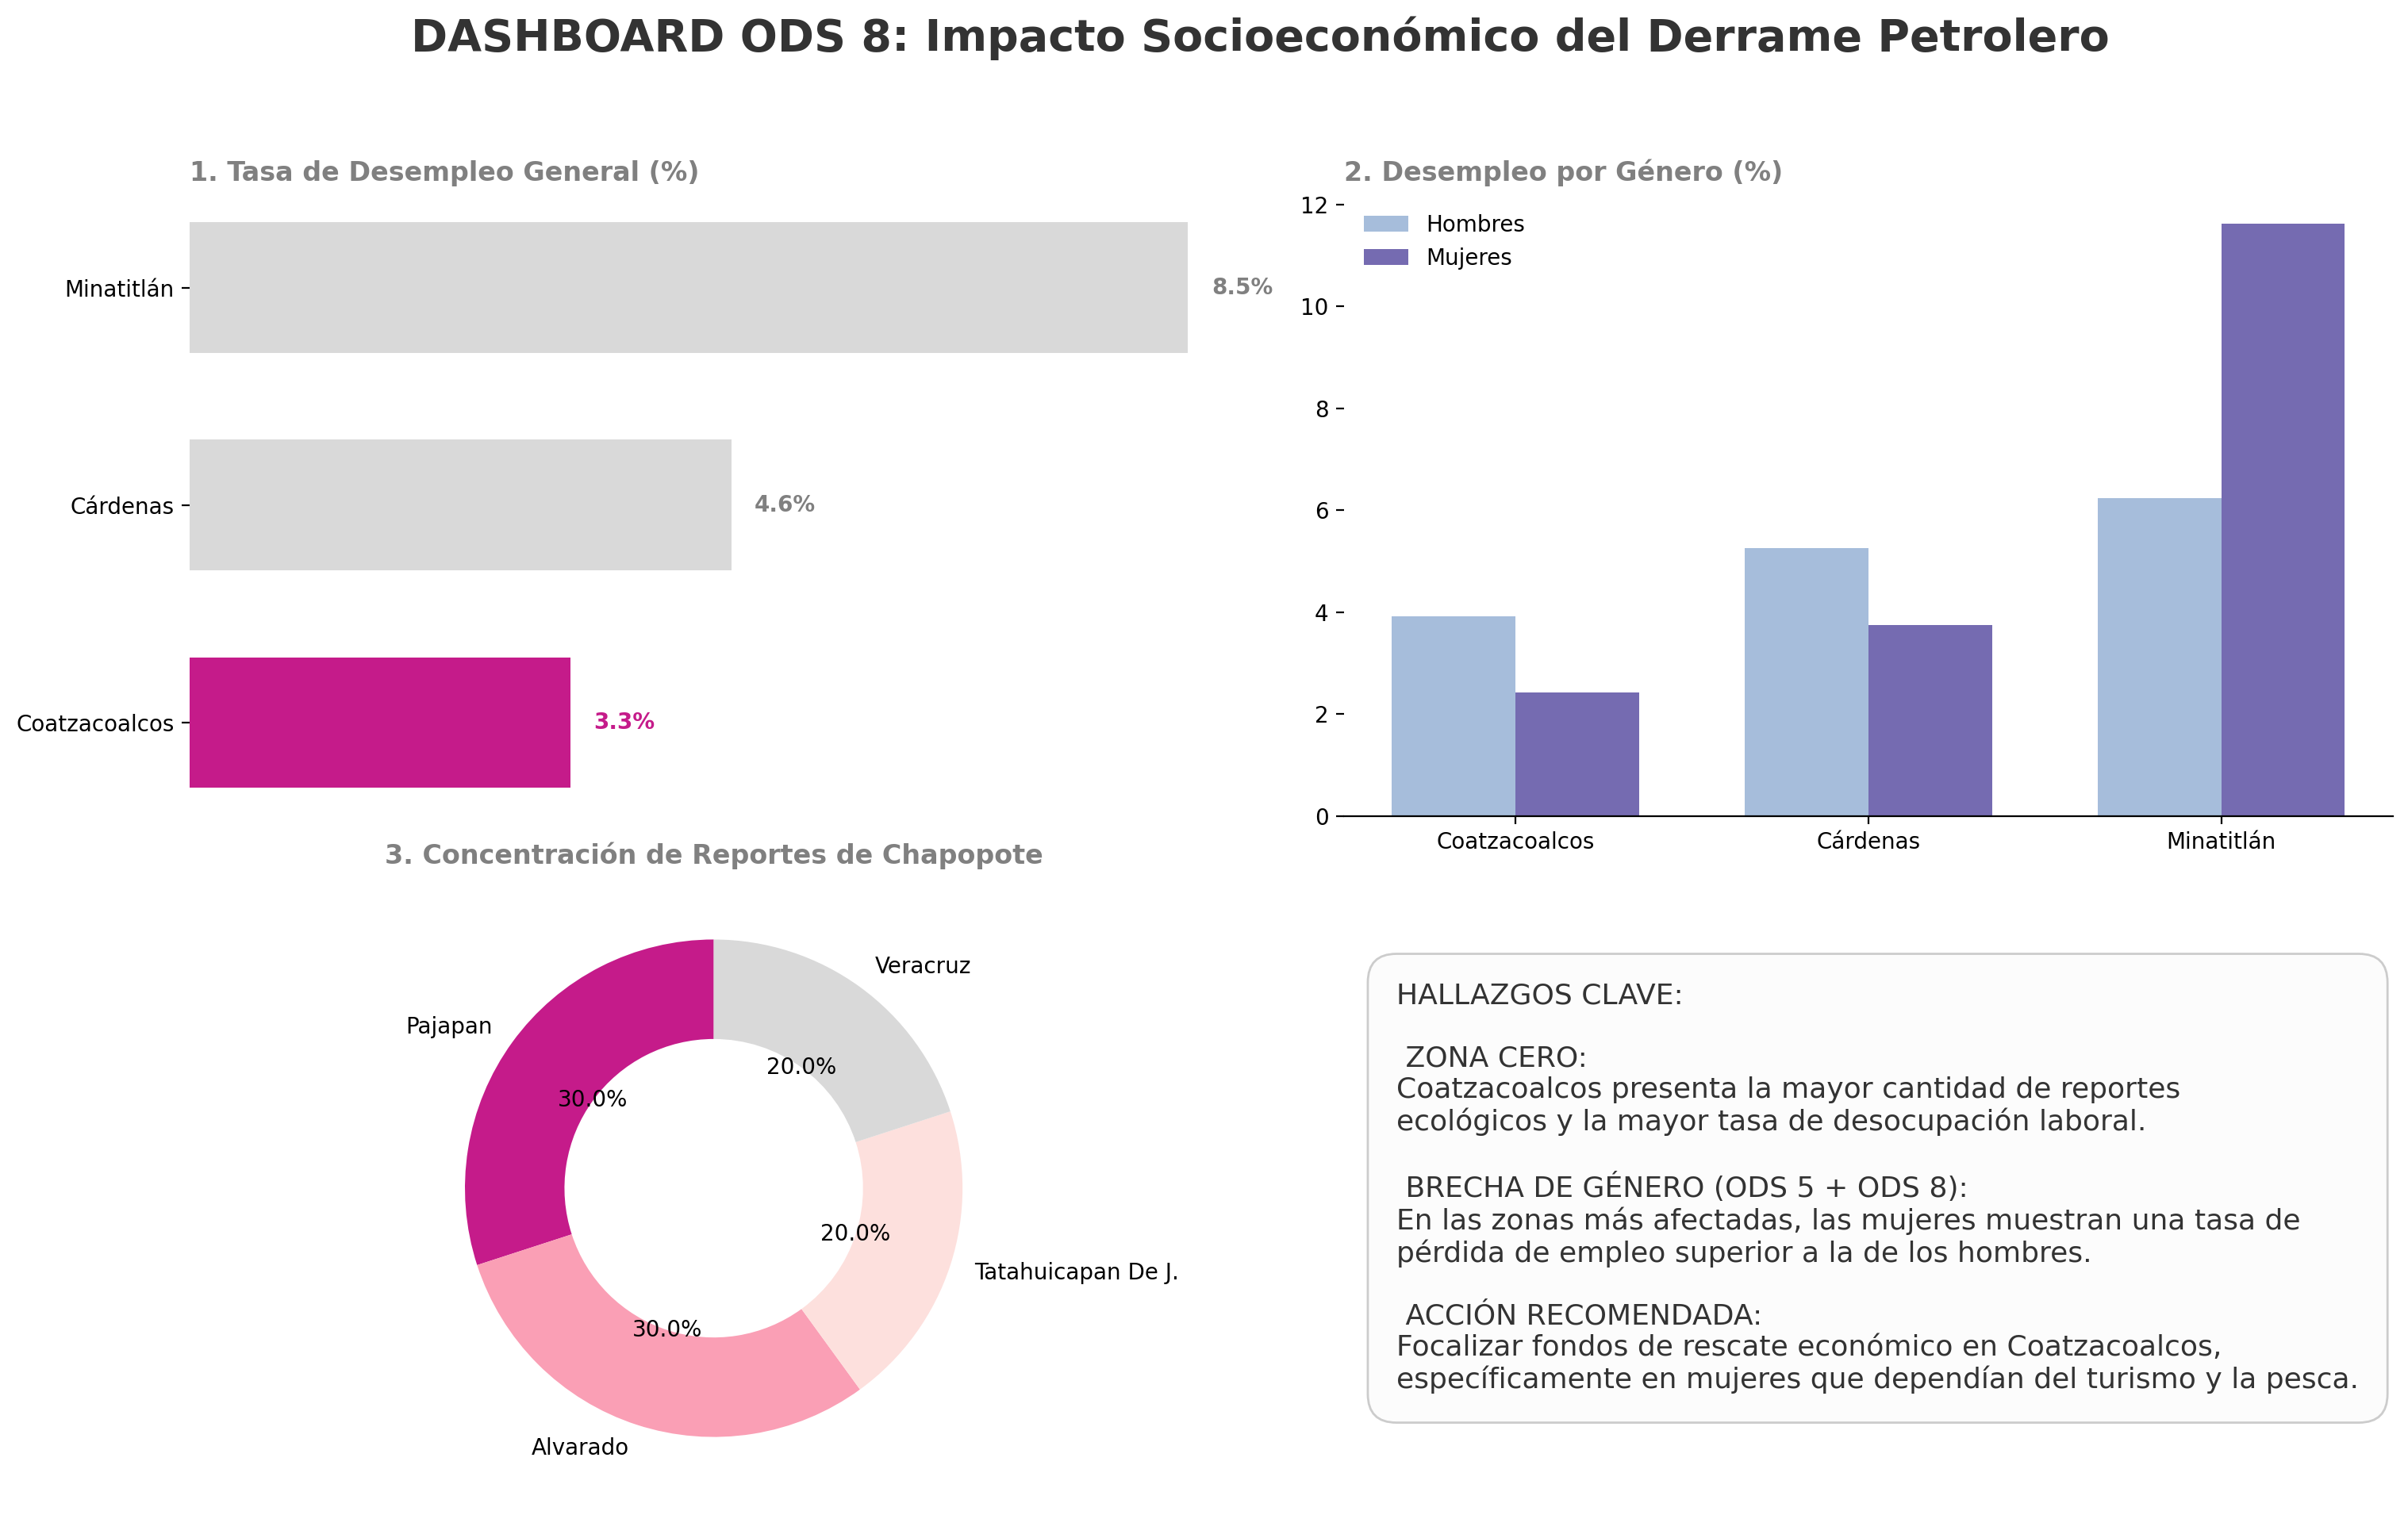

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGA DE DATOS 
df_empleo = pd.read_csv('datos_ods8_veracruz_tabasco.csv')
ruta_derrames = r"reportes_chapopote_limpios.csv"
df_derrames = pd.read_csv(ruta_derrames)

# 2. PREPARACIÓN DE DATOS 
dic_nombres = {39: 'Coatzacoalcos', 108: 'Minatitlán', 67: 'Pajapan', 2: 'Cárdenas'}
df_empleo['Municipio'] = df_empleo['mun'].map(dic_nombres).fillna('Otros')
df_top = df_empleo[df_empleo['Municipio'] != 'Otros'].copy()

# Calculamos Tasa de Desempleo General
resumen = df_top.groupby(['Municipio', 'Estatus_Laboral'])['Total_Personas'].sum().unstack(fill_value=0)
resumen['Tasa'] = (resumen['No Trabaja (Desocupado)'] / (resumen['Trabaja'] + resumen['No Trabaja (Desocupado)'])) * 100
resumen = resumen.sort_values('Tasa', ascending=True)

# Calculamos Tasa de Desempleo por Género
gen = df_top.groupby(['Municipio', 'Sexo', 'Estatus_Laboral'])['Total_Personas'].sum().unstack(fill_value=0).reset_index()
gen['Tasa'] = (gen['No Trabaja (Desocupado)'] / (gen['Trabaja'] + gen['No Trabaja (Desocupado)'])) * 100

# =======================================================
# 3. CONSTRUCCIÓN
%config InlineBackend.figure_format = 'retina'
# Creamos un lienzo grande de 2 filas por 2 columnas
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('DASHBOARD ODS 8: Impacto Socioeconómico del Derrame Petrolero', fontsize=20, fontweight='bold', color='#333333')

# --- PANEL 1: Desempleo Total 
colores_p1 = ['#c51b8a' if m == 'Coatzacoalcos' else '#d9d9d9' for m in resumen.index]
axs[0, 0].barh(resumen.index, resumen['Tasa'], color=colores_p1, height=0.6)
axs[0, 0].set_title('1. Tasa de Desempleo General (%)', loc='left', color='gray', fontweight='bold')
axs[0, 0].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
axs[0, 0].set_xticks([])

for i, v in enumerate(resumen['Tasa']):
    axs[0, 0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold', color='#c51b8a' if resumen.index[i]=='Coatzacoalcos' else 'gray')

# --- PANEL 2: Brecha de Género 
hombres = gen[gen['Sexo']=='Hombre'].set_index('Municipio')['Tasa']
mujeres = gen[gen['Sexo']=='Mujer'].set_index('Municipio')['Tasa']
x = np.arange(len(hombres.index))
width = 0.35

axs[0, 1].bar(x - width/2, hombres, width, label='Hombres', color='#a6bddb')
axs[0, 1].bar(x + width/2, mujeres, width, label='Mujeres', color='#756bb1')
axs[0, 1].set_title('2. Desempleo por Género (%)', loc='left', color='gray', fontweight='bold')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(hombres.index)
axs[0, 1].spines[['top', 'right', 'left']].set_visible(False)
axs[0, 1].legend(frameon=False)

# --- PANEL 3: Mapa de Derrames 
# Extraemos los top 4 municipios con más derrames
top_derr = df_derrames['MUN'].value_counts().head(4)
# Una gráfica de dona
axs[1, 0].pie(top_derr, labels=top_derr.index, autopct='%1.1f%%', colors=['#c51b8a', '#fa9fb5', '#fde0dd', '#d9d9d9'], startangle=90, wedgeprops=dict(width=0.4))
axs[1, 0].set_title('3. Concentración de Reportes de Chapopote', loc='center', color='gray', fontweight='bold')

# --- PANEL 4: Conclusiones 
axs[1, 1].axis('off') 
texto = (
    "HALLAZGOS CLAVE:\n\n"
    " ZONA CERO:\nCoatzacoalcos presenta la mayor cantidad de reportes\n"
    "ecológicos y la mayor tasa de desocupación laboral.\n\n"
    " BRECHA DE GÉNERO (ODS 5 + ODS 8):\n"
    "En las zonas más afectadas, las mujeres muestran una tasa de\n"
    "pérdida de empleo superior a la de los hombres.\n\n"
    " ACCIÓN RECOMENDADA:\n"
    "Focalizar fondos de rescate económico en Coatzacoalcos,\n"
    "específicamente en mujeres que dependían del turismo y la pesca."
)
axs[1, 1].text(0.05, 0.5, texto, fontsize=13, va='center', ha='left', color='#333333', 
               bbox=dict(facecolor='#fcfcfc', edgecolor='#cccccc', pad=20, boxstyle='round,pad=1'))

# Ajustamos espacios para que no se encimen
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
import pandas as pd

# 1. Cargamos el archivo de derrames (usando tu ruta absoluta corregida)
f = r"reportes_chapopote_limpios.csv"
df = pd.read_csv(f)

# 2. Filtramos Veracruz y Tabasco
df_vulnerabilidad = df[df['ESTADO'].isin(['Veracruz', 'Tabasco'])].copy()

# 3. Identificamos las "Zonas de Abandono"
# Consideramos vulnerables las playas donde Limpieza es 'Ninguna' o solo 'Comunidad'
df_vulnerabilidad['Nivel_Atencion'] = df_vulnerabilidad['Limpieza'].apply(
    lambda x: 'Atención Nula/Comunitaria' if x in ['Ninguna', 'Comunidad'] else 'Atención Institucional'
)

# 4. Resumen por municipio para el mapa
resumen_vulnerabilidad = df_vulnerabilidad.groupby(['MUN', 'Nivel_Atencion']).size().unstack(fill_value=0)
if 'Atención Nula/Comunitaria' not in resumen_vulnerabilidad:
    resumen_vulnerabilidad['Atención Nula/Comunitaria'] = 0

resumen_vulnerabilidad = resumen_vulnerabilidad.sort_values('Atención Nula/Comunitaria', ascending=False)

print("Top de Municipios con Playas sin Atención Institucional:")
display(resumen_vulnerabilidad.head())



Top de Municipios con Playas sin Atención Institucional:


Nivel_Atencion,Atención Institucional,Atención Nula/Comunitaria
MUN,,
Pajapan,2,10
Tatahuicapan De J.,0,7
Alvarado,5,7
Veracruz,1,7
Boca Del Río,0,5


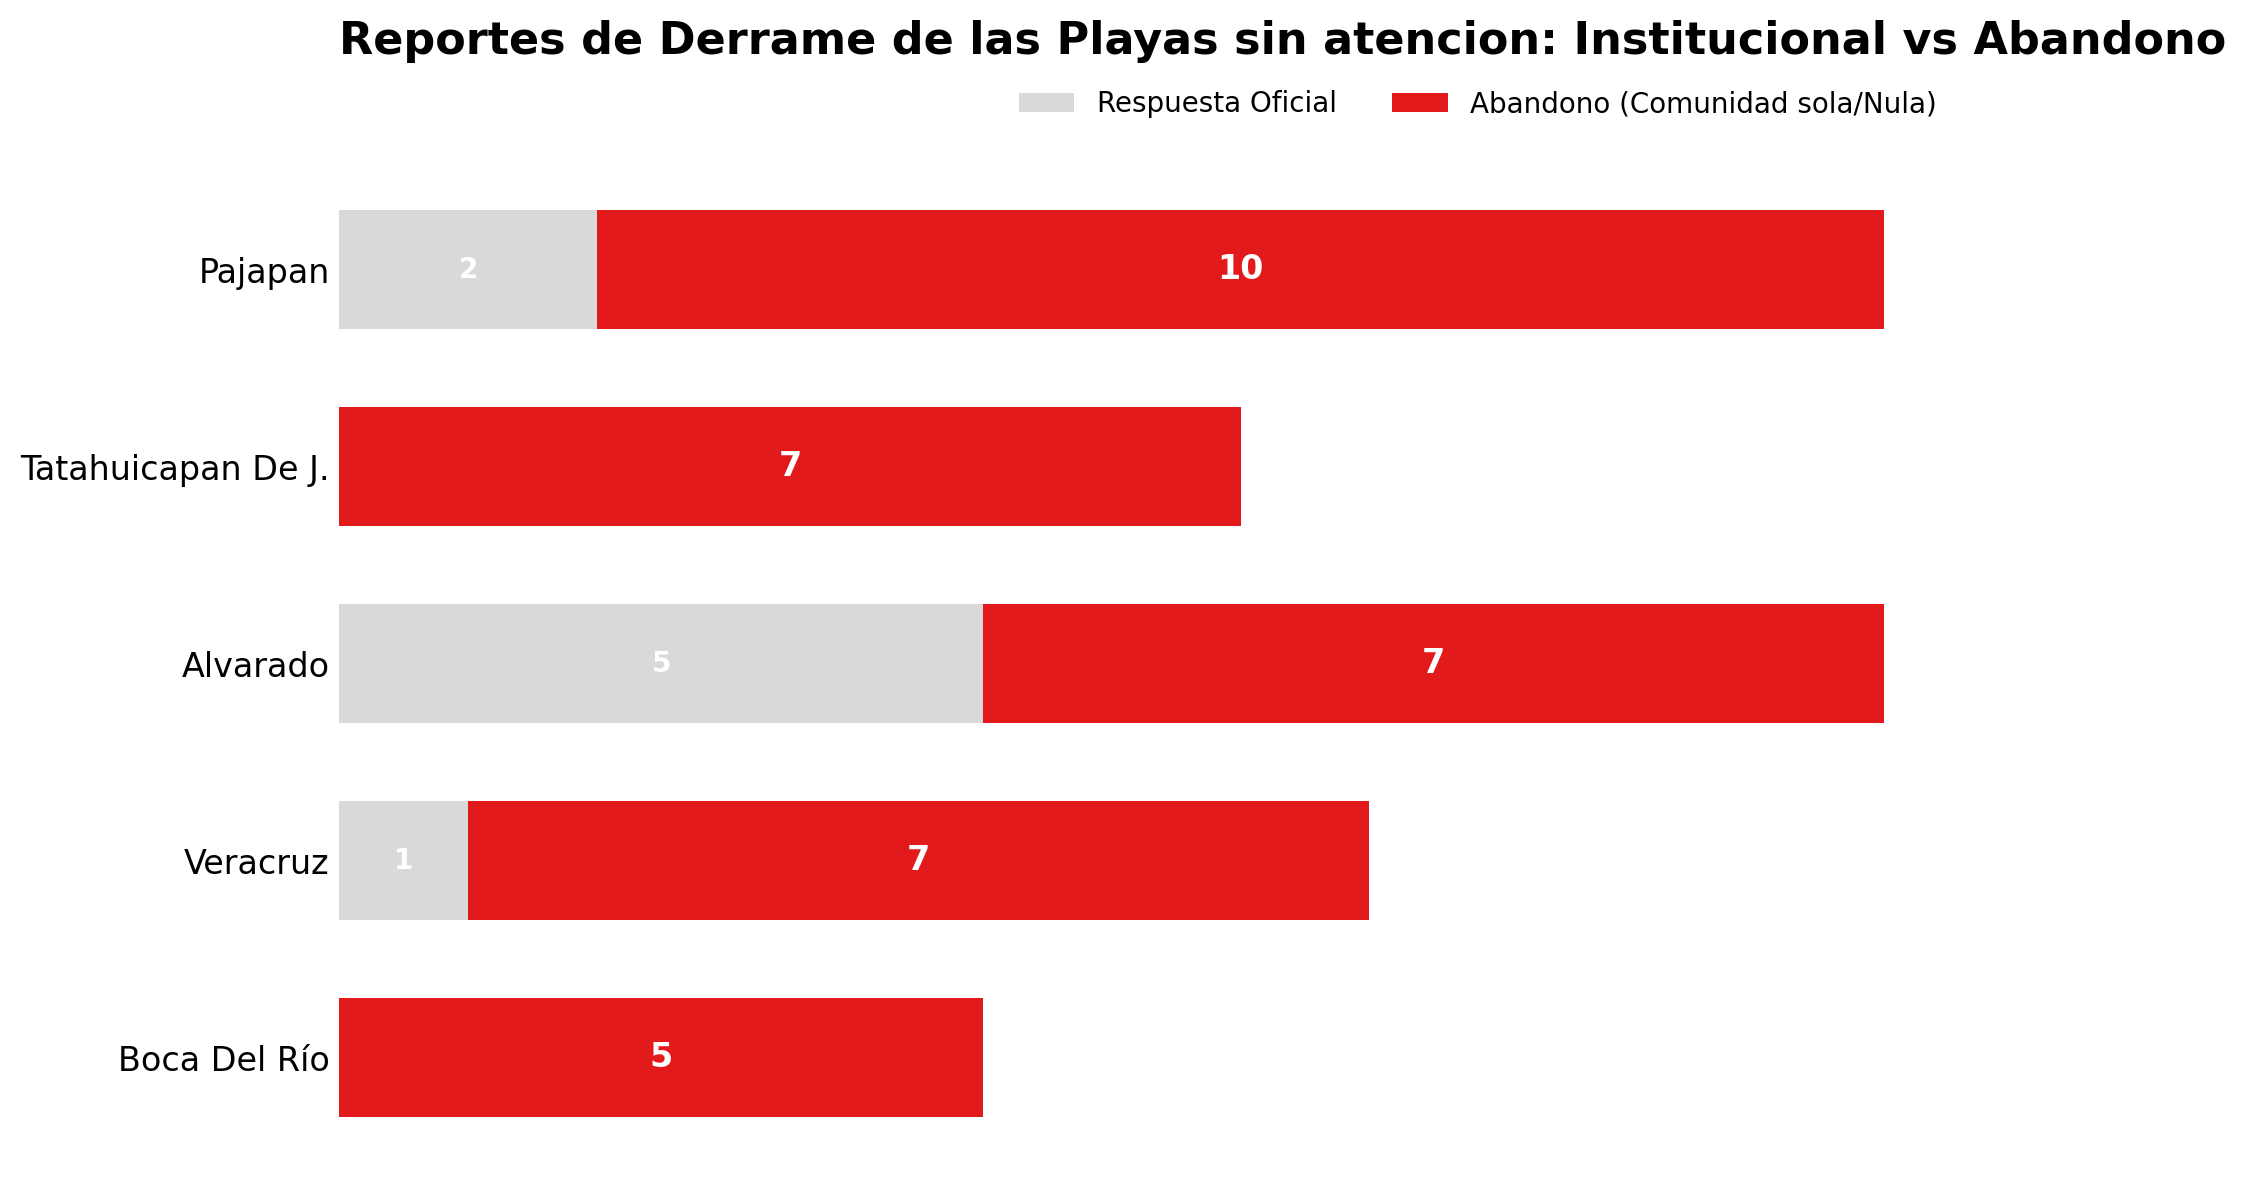

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Recreamos tus datos exactos (Para que puedas correrlo ahora mismo)
datos = {
    'MUN': ['Pajapan', 'Tatahuicapan De J.', 'Alvarado', 'Veracruz', 'Boca Del Río'],
    'Atención Institucional': [2, 0, 5, 1, 0],
    'Atención Nula/Comunitaria': [10, 7, 7, 7, 5]
}
df = pd.DataFrame(datos)

# Invertimos el orden para que el municipio con más problemas (Pajapan) quede hasta arriba en la gráfica
df = df.iloc[::-1].reset_index(drop=True)

# 2. Preparamos el lienzo
%config InlineBackend.figure_format = 'retina'
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Dibujamos las barras (El secreto está en el parámetro 'left')
# Primero la base: Lo que sí se atendió (en gris, para que no llame la atención)
ax.barh(df['MUN'], df['Atención Institucional'], 
        color='#d9d9d9', label='Respuesta Oficial', height=0.6)

# Luego la alarma: Lo que no se atendió (en rojo, apilado a la derecha de lo gris usando 'left')
ax.barh(df['MUN'], df['Atención Nula/Comunitaria'], 
        left=df['Atención Institucional'], # Esto hace que se apilen
        color='#e31a1c', label='Abandono (Comunidad sola/Nula)', height=0.6)

# 4. Limpieza Visual (Data Storytelling: Menos es Más)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) # Borramos la regla de abajo, pondremos los números en las barras
ax.tick_params(axis='y', length=0, labelsize=12) # Limpiamos el eje Y

# 5. Etiquetas de Datos (Directas, para no forzar a la audiencia a buscar)
for i, fila in df.iterrows():
    # Coordenada X del texto institucional: A la mitad de su barra
    if fila['Atención Institucional'] > 0:
        ax.text(fila['Atención Institucional']/2, i, str(fila['Atención Institucional']), 
                va='center', ha='center', color='white', fontweight='bold', fontsize=10)
    
    # Coordenada X del texto de abandono: Base gris + mitad de barra roja
    centro_rojo = fila['Atención Institucional'] + (fila['Atención Nula/Comunitaria']/2)
    ax.text(centro_rojo, i, str(fila['Atención Nula/Comunitaria']), 
            va='center', ha='center', color='white', fontweight='bold', fontsize=12)

# 6. La Leyenda y el Título
plt.legend(loc='upper right', bbox_to_anchor=(1, 1.1), frameon=False, ncol=2)

# Dejo el título genérico a propósito para tu tarea final
plt.title('Reportes de Derrame de las Playas sin atencion: Institucional vs Abandono', 
          fontsize=16, fontweight='bold', loc='left', pad=40)

plt.tight_layout()
plt.show()

1. Cargando datos...
2. Aplicando lógica de Storytelling...
3. Generando Mapa Interactivo del Golfo...


C:\Users\santi\AppData\Local\Temp\ipykernel_20316\2005561281.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


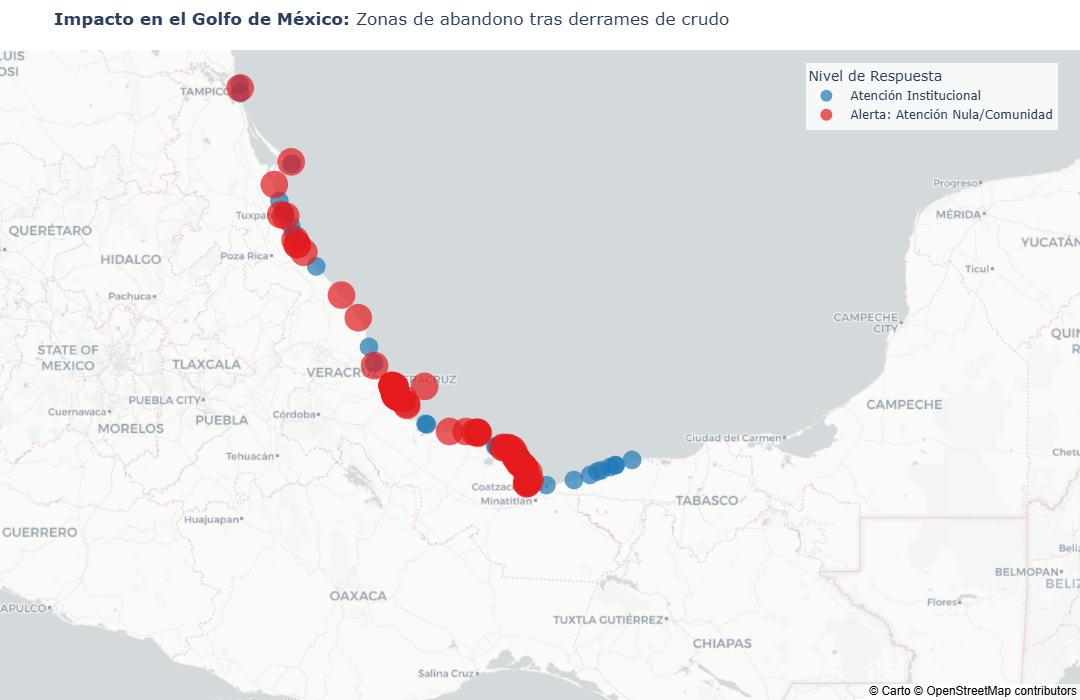

In [5]:
import pandas as pd
import plotly.express as px

print("1. Cargando datos...")
f = r"reportes_chapopote_limpios.csv"
df = pd.read_csv(f)


df = df.dropna(subset=['Latitud', 'Longitud']).copy()

print("2. Aplicando lógica de Storytelling...")

df['Estatus'] = df['Limpieza'].apply(
    lambda x: ' Alerta: Atención Nula/Comunidad' if x in ['Ninguna', 'Comunidad'] else ' Atención Institucional'
)

df['Tamaño_Visual'] = df['Limpieza'].apply(
    lambda x: 15 if x in ['Ninguna', 'Comunidad'] else 7
)

print("3. Generando Mapa Interactivo del Golfo...")
# Creamos el mapa con Plotly
fig = px.scatter_mapbox(
    df,
    lat="Latitud",
    lon="Longitud",
    color="Estatus",
    size="Tamaño_Visual",
    hover_name="SITIO_OBS", # Título al pasar el mouse
    hover_data={
        "MUN": True, 
        "Limpieza": True,
        "Tamaño_Visual": False, 
        "Latitud": False, 
        "Longitud": False
    },
    color_discrete_map={
        ' Alerta: Atención Nula/Comunidad': '#e31a1c', 
        ' Atención Institucional': '#1f78b4'           
    },
    # COORDENADAS PARA VER TODO EL ESTADO Y EL GOLFO:
    zoom=6, 
    center={"lat": 19.3, "lon": -94.5}, # Centro panorámico entre Veracruz y Tabasco
    title="<b>Impacto en el Golfo de México:</b> Zonas de abandono tras derrames de crudo",
    height=700
)


fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":50,"l":0,"b":0}, # Quitamos márgenes blancos
    legend_title_text="Nivel de Respuesta",
    
    legend=dict(
        yanchor="top", y=0.98, 
        xanchor="right", x=0.98,
        bgcolor="rgba(255, 255, 255, 0.8)"
    )
)

# Muestra el mapa interactivo directamente debajo de la celda
fig.show()